In [1]:
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from google.colab import files

In [3]:
data = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/energy_consumption_dataset.xlsx')

In [4]:
data.head(10)

,HouseID,NumberOfResidents,HouseSize,DailyTemperature,MonthlyIncome,Appliances,SolarPanels,HeatingSystem,Lighting,DailyWaterUsage,DailyElectricityUsage
0,1,3,105.923036,16.558020,4.899845,34,1,NaN,Incandescent,175.965569,40.194805
1,2,1,209.788836,-4.818491,13.574283,40,0,Gas,LED,337.918037,43.986572
2,3,5,293.122272,30.987960,19.391114,10,0,NaN,Incandescent,192.311799,62.233821
3,4,3,286.626499,0.942645,14.400536,36,1,Electric,LED,252.791711,56.163142
4,5,4,107.775756,13.022190,5.895736,36,0,Electric,Incandescent,222.095788,56.715426
5,6,9,92.724087,14.066973,6.367612,13,1,Electric,Incandescent,461.138039,76.186283
6,7,7,190.184822,-3.110549,2.765001,26,1,Electric,Incandescent,155.370799,58.045252
7,8,5,196.694322,-2.877185,14.038512,14,1,Gas,LED,309.924907,48.119298
8,9,8,215.562518,25.502072,10.850278,33,0,Gas,LED,212.441688,49.279220
9,10,6,235.372731,7.018032,4.922962,15,1,NaN,CFL,348.382000,61.028134


In [5]:
# Drop unnecessary columns if required (e.g., HouseID)
data = data.drop(columns=['HouseID'])


In [6]:
# Convert categorical columns to numeric using one-hot encoding
data = pd.get_dummies(data, columns=['HeatingSystem', 'Lighting'], drop_first=True)

In [7]:
# Check for missing values and handle them
data.fillna(data.median(), inplace=True)

In [8]:
# Define features and target
X = data.drop(columns=['DailyElectricityUsage'])
y = data['DailyElectricityUsage']

In [10]:
# Split dataset into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [12]:
# Define models
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42)
}


In [13]:
# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Model: {name}")
    print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
    print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")
    print("="*40)



Model: LinearRegression
Mean Absolute Error (MAE): 4.17
Mean Squared Error (MSE): 26.51
R2 Score: 0.85
Model: DecisionTree
Mean Absolute Error (MAE): 6.82
Mean Squared Error (MSE): 71.42
R2 Score: 0.60
Model: RandomForest
Mean Absolute Error (MAE): 4.97
Mean Squared Error (MSE): 35.84
R2 Score: 0.80


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

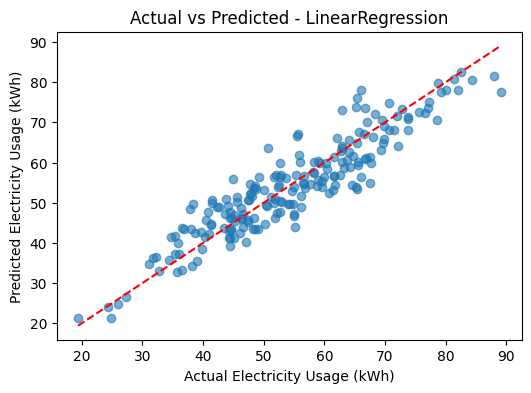

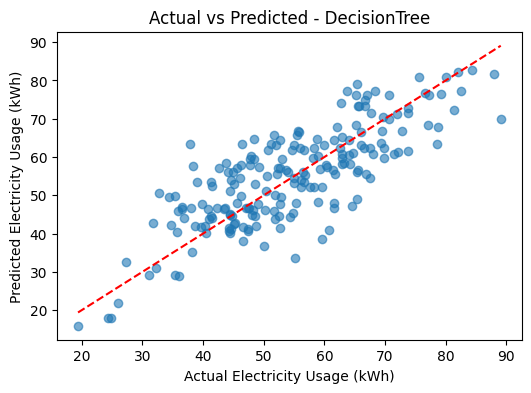

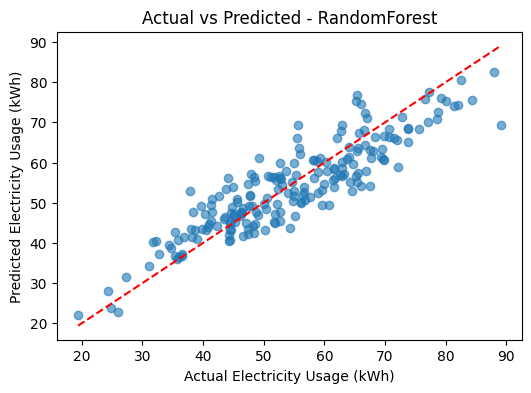

In [15]:
# Actual vs Predicted plot
for name, model in models.items():
    y_pred = model.predict(X_test)

    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
    plt.xlabel("Actual Electricity Usage (kWh)")
    plt.ylabel("Predicted Electricity Usage (kWh)")
    plt.title(f"Actual vs Predicted - {name}")
    plt.show()

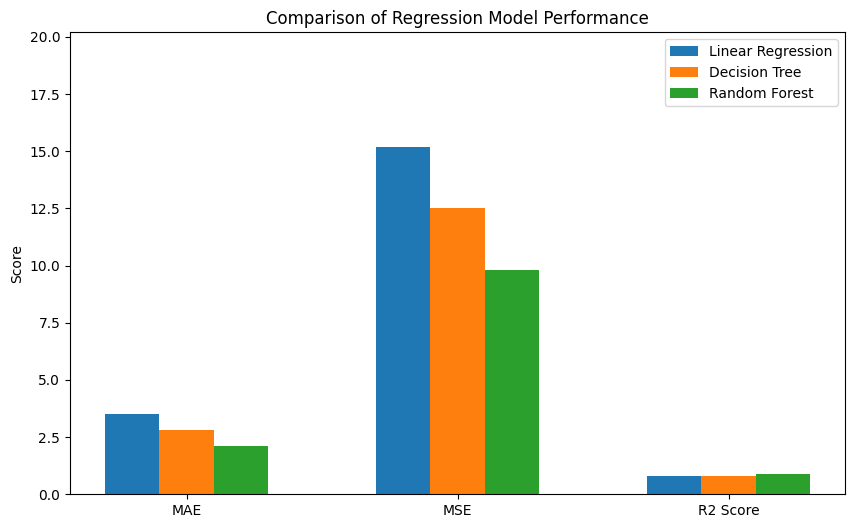

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Example regression performance data (modify with actual results)
model_reports = {
    'Linear Regression': {'MAE': 3.5, 'MSE': 15.2, 'R2': 0.78},
    'Decision Tree': {'MAE': 2.8, 'MSE': 12.5, 'R2': 0.82},
    'Random Forest': {'MAE': 2.1, 'MSE': 9.8, 'R2': 0.88}
}

# Define metrics to plot
metrics = ['MAE', 'MSE', 'R2 Score']
x = np.arange(len(metrics))  # X-axis positions

# Set bar width
width = 0.2

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))

for i, (model_name, report) in enumerate(model_reports.items()):
    scores = [report['MAE'], report['MSE'], report['R2']]
    ax.bar(x + i * width, scores, width, label=model_name)

# Set plot properties
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Comparison of Regression Model Performance')
ax.legend()
ax.set_ylim([0, max(max(report.values()) for report in model_reports.values()) + 5])  # Adjust y-axis dynamically

plt.show()
